In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy
print("all good")

Matplotlib is building the font cache; this may take a moment.


all good


In [2]:
import pandas as pd
df = pd.read_csv("data/C10_F.csv")
df.head()

,loggingTime(txt),locationTimestamp_since1970(s),locationLatitude(WGS84),locationLongitude(WGS84),locationAltitude(m),locationSpeed(m/s),locationSpeedAccuracy(m/s),locationCourse(°),locationCourseAccuracy(°),locationVerticalAccuracy(m),...,pedometerDistance(m),pedometerFloorAscended(N),pedometerFloorDescended(N),pedometerEndDate(txt),altimeterTimestamp_sinceReboot(s),altimeterReset(bool),altimeterRelativeAltitude(m),altimeterPressure(kPa),batteryState(N),batteryLevel(R)
0,2024-04-10T17:55:41.808+08:00,1.712743e+09,27.561584,109.986628,235.8286,-1,-1,-1,-1,18.061241,...,6731.874,12,9,2024-04-10T17:55:36.984+08:00,7.344357e+08,0,-153.36,98.56832,1,0.4
1,2024-04-10T17:55:41.809+08:00,1.712743e+09,27.561584,109.986628,235.8286,-1,-1,-1,-1,18.061241,...,6731.874,12,9,2024-04-10T17:55:36.984+08:00,7.344357e+08,0,-153.36,98.56832,1,0.4
2,2024-04-10T17:55:41.810+08:00,1.712743e+09,27.561584,109.986628,235.8286,-1,-1,-1,-1,18.061241,...,6731.874,12,9,2024-04-10T17:55:36.984+08:00,7.344357e+08,0,-153.36,98.56832,1,0.4
3,2024-04-10T17:55:41.819+08:00,1.712743e+09,27.561584,109.986628,235.8286,-1,-1,-1,-1,18.061241,...,6731.874,12,9,2024-04-10T17:55:36.984+08:00,7.344357e+08,0,-153.36,98.56832,1,0.4
4,2024-04-10T17:55:41.827+08:00,1.712743e+09,27.561584,109.986628,235.8286,-1,-1,-1,-1,18.061241,...,6731.874,12,9,2024-04-10T17:55:36.984+08:00,7.344357e+08,0,-153.36,98.56832,1,0.4


In [3]:
print(list(df.columns))

['loggingTime(txt)', 'locationTimestamp_since1970(s)', 'locationLatitude(WGS84)', 'locationLongitude(WGS84)', 'locationAltitude(m)', 'locationSpeed(m/s)', 'locationSpeedAccuracy(m/s)', 'locationCourse(°)', 'locationCourseAccuracy(°)', 'locationVerticalAccuracy(m)', 'locationHorizontalAccuracy(m)', 'locationFloor(Z)', 'accelerometerTimestamp_sinceReboot(s)', 'accelerometerAccelerationX(G)', 'accelerometerAccelerationY(G)', 'accelerometerAccelerationZ(G)', 'motionTimestamp_sinceReboot(s)', 'motionYaw(rad)', 'motionRoll(rad)', 'motionPitch(rad)', 'motionRotationRateX(rad/s)', 'motionRotationRateY(rad/s)', 'motionRotationRateZ(rad/s)', 'motionUserAccelerationX(G)', 'motionUserAccelerationY(G)', 'motionUserAccelerationZ(G)', 'motionAttitudeReferenceFrame(txt)', 'motionQuaternionX(R)', 'motionQuaternionY(R)', 'motionQuaternionZ(R)', 'motionQuaternionW(R)', 'motionGravityX(G)', 'motionGravityY(G)', 'motionGravityZ(G)', 'motionMagneticFieldX(µT)', 'motionMagneticFieldY(µT)', 'motionMagneticFie

In [4]:
print(len(df))
print(df['loggingTime(txt)'].iloc[0], "→", df['loggingTime(txt)'].iloc[-1])

6840
2024-04-10T17:55:41.808+08:00 → 2024-04-10T17:56:50.545+08:00


In [5]:
df_t = pd.read_csv("data/C10_T.csv", nrows=5)
print(list(df_t.columns) == list(df.columns))
print(df_t['loggingTime(txt)'].iloc[0])

False


KeyError: 'loggingTime(txt)'

In [6]:
print(list(df_t.columns))

['loggingTime(txt);locationTimestamp_since1970(s);locationLatitude(WGS84);locationLongitude(WGS84);locationAltitude(m);locationSpeed(m/s);locationSpeedAccuracy(m/s);locationCourse(°);locationCourseAccuracy(°);locationVerticalAccuracy(m);locationHorizontalAccuracy(m);locationFloor(Z);accelerometerTimestamp_sinceReboot(s);accelerometerAccelerationX(G);accelerometerAccelerationY(G);accelerometerAccelerationZ(G);motionTimestamp_sinceReboot(s);motionYaw(rad);motionRoll(rad);motionPitch(rad);motionRotationRateX(rad/s);motionRotationRateY(rad/s);motionRotationRateZ(rad/s);motionUserAccelerationX(G);motionUserAccelerationY(G);motionUserAccelerationZ(G);motionAttitudeReferenceFrame(txt);motionQuaternionX(R);motionQuaternionY(R);motionQuaternionZ(R);motionQuaternionW(R);motionGravityX(G);motionGravityY(G);motionGravityZ(G);motionMagneticFieldX(µT);motionMagneticFieldY(µT);motionMagneticFieldZ(µT);motionHeading(°);motionMagneticFieldCalibrationAccuracy(Z);activityTimestamp_sinceReboot(s);activity

In [7]:
df_t = pd.read_csv("data/C10_T.csv", nrows=5, sep=";")
print(df_t['loggingTime(txt)'].iloc[0])

2023-12-28T16:43:43.633+08:00


In [8]:
labels = pd.read_csv("data/Demographic and mental health data.csv")
print(labels.shape)
print(list(labels.columns))
labels

(58, 55)
['ID', 'SEX', 'BMI', 'height(cm)', 'weight(kg)', 'SDQ1', 'SDQ2', 'SDQ3', 'SDQ4', 'SDQ5', 'SDQ6', 'SDQ7', 'SDQ8', 'SDQ9', 'SDQ10', 'SDQ11', 'SDQ12', 'SDQ13', 'SDQ14', 'SDQ15', 'SDQ16', 'SDQ17', 'SDQ18', 'SDQ20', 'SDQ21', 'SDQ22', 'SDQ23', 'SDQ24', 'SDQ25', 'a1', 'a2', 'a3', 'a4', 'a5', 'a6', 'a7', 'a8', 'a9', 'a10', 'a11', 'a12', 'a13', 'a14', 'a15', 'a16', 'a17', 'a18', 'a19', 'a20', 'a21', 'a22', 'a23', 'a24', 'a25', 'a26']


,ID,SEX,BMI,height(cm),weight(kg),SDQ1,SDQ2,SDQ3,SDQ4,SDQ5,...,a17,a18,a19,a20,a21,a22,a23,a24,a25,a26
0,H1,female,15.4,125.0,24.0,3.0,1.0,1.0,3.0,1.0,...,1.0,1.0,2.0,2.0,2.0,1.0,1.0,1.0,1.0,1.0
1,W4,male,15.9,128.0,26.0,3.0,3.0,1.0,2.0,2.0,...,1.0,1.0,2.0,2.0,2.0,2.0,1.0,2.0,2.0,1.0
2,Z5,female,14.3,140.0,28.0,2.0,2.0,1.0,2.0,2.0,...,1.0,2.0,1.0,2.0,2.0,1.0,1.0,1.0,1.0,1.0
3,Z7,male,22.4,140.0,44.0,3.0,2.0,1.0,3.0,1.0,...,1.0,1.0,2.0,2.0,2.0,1.0,1.0,1.0,1.0,1.0
4,W53,female,19.2,135.0,35.0,3.0,3.0,2.0,3.0,3.0,...,1.0,2.0,3.0,2.0,2.0,1.0,2.0,2.0,1.0,1.0
5,Z14,male,17.4,120.0,25.0,3.0,1.0,1.0,3.0,1.0,...,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0
6,L51,female,13.9,120.0,20.0,2.0,1.0,1.0,2.0,2.0,...,1.0,1.0,2.0,2.0,2.0,1.0,2.0,2.0,2.0,1.0
7,L16,male,14.2,130.0,24.0,3.0,3.0,1.0,2.0,2.0,...,1.0,3.0,3.0,2.0,2.0,2.0,2.0,2.0,1.0,1.0
8,Y52,male,20.8,155.0,50.0,2.0,1.0,1.0,3.0,2.0,...,1.0,2.0,4.0,4.0,4.0,3.0,3.0,4.0,1.0,1.0
9,Y54,male,13.4,122.0,20.0,3.0,3.0,1.0,1.0,3.0,...,2.0,2.0,2.0,2.0,2.0,2.0,3.0,4.0,2.0,2.0


In [9]:
import os

files = os.listdir("data")

f_ids = sorted([f.replace("_F.csv", "") for f in files if f.endswith("_F.csv")])
t_ids = sorted([f.replace("_T.csv", "") for f in files if f.endswith("_T.csv")])

print("F文件:", len(f_ids), f_ids)
print("T文件:", len(t_ids), t_ids)


F文件: 50 ['B26', 'C10', 'C28', 'C41', 'C42', 'C43', 'G40', 'H1', 'H2', 'H44', 'H45', 'H46', 'H47', 'H48', 'H49', 'H50', 'J33', 'J34', 'L15', 'L16', 'L17', 'L18', 'L29', 'L3', 'L30', 'M19', 'P35', 'P9', 'S25', 'S32', 'S6', 'T20', 'T24', 'T37', 'T38', 'W21', 'W22', 'W23', 'W4', 'X31', 'Y36', 'Z11', 'Z12', 'Z13', 'Z14', 'Z27', 'Z39', 'Z5', 'Z7', 'Z8']
T文件: 33 ['C10', 'C28', 'C43', 'F55', 'H2', 'H44', 'H45', 'H46', 'H47', 'H48', 'H50', 'J34', 'L16', 'L29', 'L3', 'L51', 'S32', 'T20', 'W22', 'W23', 'W53', 'X31', 'Y36', 'Y52', 'Y54', 'Y55', 'Y56', 'Y57', 'Z14', 'Z39', 'Z5', 'Z7', 'Z8']


In [10]:
label_ids = set(labels["ID"])
data_ids = set(f_ids) | set(t_ids)

both = data_ids & label_ids
data_only = data_ids - label_ids
label_only = label_ids - data_ids

print("有数据+有标签:", len(both), sorted(both))
print("有数据无标签:", sorted(data_only))
print("有标签无数据:", sorted(label_only))

有数据+有标签: 57 ['B26', 'C10', 'C28', 'C41', 'C42', 'C43', 'F55', 'G40', 'H1', 'H2', 'H44', 'H45', 'H46', 'H47', 'H48', 'H49', 'H50', 'J33', 'J34', 'L15', 'L16', 'L17', 'L18', 'L29', 'L3', 'L30', 'L51', 'M19', 'P35', 'P9', 'S25', 'S32', 'S6', 'T20', 'T24', 'T37', 'T38', 'W21', 'W22', 'W23', 'W4', 'W53', 'X31', 'Y36', 'Y52', 'Y54', 'Y55', 'Y56', 'Y57', 'Z11', 'Z12', 'Z13', 'Z14', 'Z39', 'Z5', 'Z7', 'Z8']
有数据无标签: ['Z27']
有标签无数据: ['Q27']


In [11]:
labels["ID"] = labels["ID"].replace("Q27", "Z27")

sdq_cols = [c for c in labels.columns if c.startswith("SDQ")]
snap_cols = [c for c in labels.columns if c.startswith("a")]

labels["sdq_missing"] = labels[sdq_cols].isna().sum(axis=1)
labels["snap_missing"] = labels[snap_cols].isna().sum(axis=1)

problem = labels[(labels["sdq_missing"] > 0) | (labels["snap_missing"] > 0)]
print(problem[["ID", "sdq_missing", "snap_missing"]])

     ID  sdq_missing  snap_missing
11  T24           24             0
13  L30            0            26
16  J33           24            26
33  T20           24             0
36  S32            1             0
41  H50            0            26
42  W21           24            26
48  H44           24            26
49  C10           24            26
52   S6            0            26
54  C41           24            26
55  M19           24            26


In [12]:
sdq_hyper_items = ["SDQ2", "SDQ10", "SDQ15", "SDQ21", "SDQ25"]

s = labels[sdq_hyper_items].copy()
s["SDQ21"] = 4 - s["SDQ21"]
s["SDQ25"] = 4 - s["SDQ25"]
labels["sdq_hyper"] = (s - 1).sum(axis=1, min_count=5)

labels["snap_inatt"] = labels[[f"a{i}" for i in range(1, 10)]].mean(axis=1)
labels["snap_hyper"] = labels[[f"a{i}" for i in range(10, 19)]].mean(axis=1)

labels[["ID", "sdq_hyper", "snap_inatt", "snap_hyper"]].sort_values("sdq_hyper", ascending=False).head(15)

,ID,sdq_hyper,snap_inatt,snap_hyper
9,Y54,9.0,3.000000,2.222222
7,L16,7.0,2.111111,2.000000
28,L15,7.0,2.666667,1.555556
1,W4,7.0,1.777778,1.666667
18,T37,7.0,2.555556,2.000000
4,W53,6.0,1.888889,1.666667
37,Y36,6.0,2.222222,1.666667
31,Y56,6.0,2.111111,1.444444
26,P9,5.0,1.555556,1.666667
17,J34,5.0,2.222222,2.222222


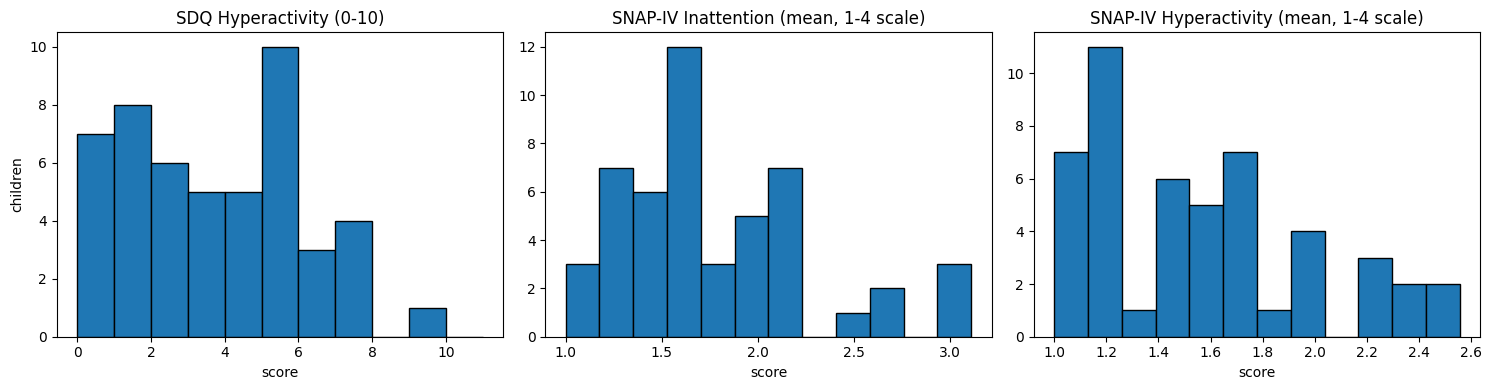

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(labels["sdq_hyper"].dropna(), bins=range(0, 12), edgecolor="black")
axes[0].set_title("SDQ Hyperactivity (0-10)")
axes[0].set_xlabel("score"); axes[0].set_ylabel("children")

axes[1].hist(labels["snap_inatt"].dropna(), bins=12, edgecolor="black")
axes[1].set_title("SNAP-IV Inattention (mean, 1-4 scale)")
axes[1].set_xlabel("score")

axes[2].hist(labels["snap_hyper"].dropna(), bins=12, edgecolor="black")
axes[2].set_title("SNAP-IV Hyperactivity (mean, 1-4 scale)")
axes[2].set_xlabel("score")

plt.tight_layout()
plt.show()

In [15]:
labels["snap_inatt_sum"] = labels[[f"a{i}" for i in range(1, 10)]].sum(axis=1, min_count=9)
labels["snap_hyper_sum"] = labels[[f"a{i}" for i in range(10, 19)]].sum(axis=1, min_count=9)

result = labels[["ID", "snap_inatt_sum", "snap_hyper_sum"]].sort_values(
    "snap_inatt_sum", ascending=False
)
print(result.to_string())


     ID  snap_inatt_sum  snap_hyper_sum
24   H2            28.0            23.0
22  H46            27.0            22.0
9   Y54            27.0            20.0
28  L15            24.0            14.0
47  C28            24.0            14.0
18  T37            23.0            18.0
17  J34            20.0            20.0
43  Z11            20.0            16.0
37  Y36            20.0            15.0
15  F55            20.0            15.0
32  Y57            20.0            20.0
31  Y56            19.0            13.0
7   L16            19.0            18.0
40  H49            18.0            21.0
5   Z14            18.0            21.0
56  Z12            17.0            13.0
25   L3            17.0            18.0
4   W53            17.0            15.0
1    W4            16.0            15.0
57  H45            16.0            13.0
34  W23            16.0            15.0
36  S32            15.0            13.0
39  G40            15.0            14.0
20  C42            15.0            13.0


In [16]:
inatt_rank = labels[["ID", "snap_inatt_sum"]].dropna().sort_values(
    "snap_inatt_sum", ascending=False
)
print("=== SNAP 注意缺陷维度（a1-a9总分，满分36）===")
print(inatt_rank.to_string(index=False))

hyper_rank = labels[["ID", "snap_hyper_sum"]].dropna().sort_values(
    "snap_hyper_sum", ascending=False
)
print("\n=== SNAP 多动/冲动维度（a10-a18总分，满分36）===")
print(hyper_rank.to_string(index=False))

=== SNAP 注意缺陷维度（a1-a9总分，满分36）===
 ID  snap_inatt_sum
 H2            28.0
H46            27.0
Y54            27.0
L15            24.0
C28            24.0
T37            23.0
J34            20.0
Z11            20.0
Y36            20.0
F55            20.0
Y57            20.0
Y56            19.0
L16            19.0
H49            18.0
Z14            18.0
Z12            17.0
 L3            17.0
W53            17.0
 W4            16.0
H45            16.0
W23            16.0
S32            15.0
G40            15.0
C42            15.0
L51            15.0
Z27            15.0
Y52            15.0
L18            15.0
Y55            15.0
H48            15.0
T38            14.0
 P9            14.0
T24            14.0
T20            13.0
L29            13.0
 Z8            13.0
Z13            13.0
 H1            13.0
C43            13.0
W22            12.0
Z39            12.0
B26            12.0
H47            12.0
 Z5            12.0
X31            11.0
P35            11.0
 Z7            10.0
S25    